In [1]:
# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Fuzzy matching
from thefuzz import fuzz, process

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

#Feature Selection
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy import stats


# Models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    median_absolute_error, mean_absolute_percentage_error,
    root_mean_squared_error, make_scorer
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


# For imputation
# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer


In [2]:
import sys
print(sys.path[0])


/opt/anaconda3/envs/Fall2526/lib/python312.zip


In [ ]:
url = "https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/main/train.csv"

df = pd.read_csv("train.csv")
df.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


# Data Exploration unprocessed Data

In [4]:
print(df.shape)

(75973, 14)


In [5]:
#df.carID.count() # No duplicates for CarID

In [6]:
df.describe()

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


In [7]:
df.dtypes

carID               int64
Brand              object
model              object
year              float64
price               int64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object

In [8]:
df.isna().sum()

carID                0
Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64

# Data Cleaning

## Data Preprocessing Overview
The goal of the Data Preprocessing workflow is to perform the necessary steps to transform both the training and testing data sets into a shape with no value outlieres and no missing values. For this a custom function was created which performs the necessary preprocessing steps on both datasets. Additionally, the function ensures no dataleakage by fitting the preprocessing steps only on the training data and then applying the same preprocessing steps to both the training and test data. Since the goal of the function is Data Cleaning no addtional columns are created and the returing dataframe are of the same shape as the input.

The preprocessing steps are performed in the following order:


### Preprocessing steps by Column

| Column | General Preprocessing | Imputation Method | Notes |
|--------|----------------------|-------------------|-------|
| **carID** | None | No imputation (identifier) | Unique identifier, not used in modeling |
| **Brand** | - Lowercase & strip whitespace<br>- Dictionary mapping for typo correction<br>- Fill missing based on model mode | KNNImputer (k=10, distance-weighted) | Imputed using similar cars based on all features, this is the case for when model and brand are missing |
| **model** | - Lowercase & strip whitespace<br>- Vectorized fuzzy matching against reference list<br>- Separate handling for 2-letter models | Brand-specific KNNImputer (k=10) | Imputed within each brand to ensure brand-model consistency |
| **year** | - Round to integer | IterativeImputer (mean) | Imputed using relationships with all other features |
| **transmission** | - Lowercase & strip whitespace<br>- Vectorized fuzzy matching against reference list<br>- Replace "unknown" and "other" with missing | KNNImputer (k=10, distance-weighted) | Imputed using similar cars based on all features |
| **mileage** | - Round to integer | IterativeImputer (mean) | Imputed using relationships with all other features |
| **fuelType** | - Lowercase & strip whitespace<br>- Vectorized fuzzy matching against reference list<br>- Replace "other" with missing | KNNImputer (k=10, distance-weighted) | Imputed using similar cars based on all features |
| **tax** | - Round to integer | IterativeImputer (mean) | Imputed using relationships with all other features |
| **mpg** | - Round to 1 decimal place | IterativeImputer (mean) | Imputed using relationships with all other features |
| **engineSize** | - Round to 1 decimal place | IterativeImputer (mean) | Imputed using relationships with all other features |
| **paintQuality%** | - Round to integer<br>- Fix data entry errors:<br>&nbsp;&nbsp;• Values <4: multiply by 10<br>&nbsp;&nbsp;• Values >100: subtract 100 | IterativeImputer (mean) | Imputed using relationships with all other features |
| **previousOwners** | - Round to integer<br>- Take absolute value | IterativeImputer (mean) | Imputed using relationships with all other features |
| **hasDamage** | - Convert to boolean<br>- Invert to create `stated_no_damage`<br>- Drop original column | No imputation needed | Transformed to `stated_no_damage` (True/False) |


- **Data Leakage Note**: All imputers and encoders are fitted **only on training data**, then transformed on both train and test sets


#### Additional explanations for selected Columns pre-processing

<b> Brand column </b> <br>
We decided to do "manual" brand mapping because it gives the biggest controll factor while the number of values is managable. 
Also with some of the brand names beeing very short (e.g. vw) fuzzy algorithms would perform with reduced accuracy. For the limited number of entries where both Brand and Model are missing (around 40), we used imputing for finding the Brand value.

<b> paint Quality column </b> <br>
The two data clearing issues that had to be resolved in this columne where values below 4 and values above 100. As descibed in the project handout the values are entered by the mechanic during assesment and should be a percentage value. Due to the way the data is collecte we conculeded that the out of line values are caused by the mechanics not entering the correct value. Thus we applied simple mathematical operations to the column to resolve the issues. For the values below 4 we multipled the value by 10, puting them in line with the other column values. For values above 100 we subtracted 100 assuming the mechanic mistook the units when entering the value. The resulting column values are all in the range of 0-100.

<b> Year column </b> <br>
This is a column that is filled by the customer prior to inspection. If the car has no damage the customer fills it in, the other values are left empty. Since it is impossible to determine the level of damage from all the other datapoints we decided to make changes to the column hasDamage. Mainly we change the purpose of the column to assesing if the customer stated that his car has no damage, in this case true (previous 0), else fales (previous missing).

In [9]:
def clean_car_data(df_train, df_test, fast=True):
    """
    Clean and impute car data for both training and test sets.
    
    IMPORTANT: All imputers and encoders are fit ONLY on training data to prevent data leakage.
    
    Parameters:
    -----------
    df_train : pd.DataFrame
        Training dataset
    df_test : pd.DataFrame
        Test dataset
    fast : bool, default=True
        If True, uses BayesianRidge for imputation (fast).
        If False, uses RandomForestRegressor (slower but potentially better accuracy)
        
    Returns:
    --------
    df_train_cleaned : pd.DataFrame
        Cleaned and imputed training data
    df_test_cleaned : pd.DataFrame
        Cleaned and imputed test data
    """
    
    # ============================================================================
    # SECTION 1: REFERENCE DATA SETUP
    # ============================================================================
    
    # Reference list of correct model names
    models = ["golf", "veloste", "caddy", "yaris", "q2", "fiesta", "2 series", "3 series", "a3", "octavia", 
              "passat", "focus", "insignia", "a class", "q3", "fabia", "ka+", "glc class", "i30", "c class", 
              "polo", "e class", "q5", "up", "c-hr", "mokka x", "corsa", "astra", "tt", "5 series", "aygo", 
              "4 series", "slk", "viva", "t-roc", "ecosport", "tucson", "x-class", "cl class", "ix20", "i20", 
              "rapid", "a1", "auris", "sharan", "adam", "x3", "a8", "gls class", "b-max", "a4", "kona", "i10", 
              "mokka", "s-max", "x2", "crossland x", "tiguan", "a5", "gle class", "zafira", "ioniq", "a6", 
              "mondeo", "yeti outdoor", "x1", "scala", "s class", "1 series", "kamiq", "kuga", "tourneo connect", 
              "q7", "gla class", "arteon", "sl class", "santa fe", "grandland x", "i800", "rav4", "touran", 
              "citigo", "roomster", "prius", "corolla", "b class", "kodiaq", "v class", "caddy maxi life", 
              "superb", "getz", "combo life", "beetle", "galaxy", "m3", "gtc", "x4", "ka", "ix35", 
              "grand tourneo connect", "m4", "tourneo custom", "z4", "x5", "meriva", "rs6", "verso", "touareg", 
              "shuttle", "cls class", "c-max", "puma", "cla class", "i40", "tiguan allspace", "6 series", 
              "caravelle", "karoq", "i3", "grand c-max", "t-cross", "a7", "golf sv", "agila", "gt86", "yeti", 
              "california", "land cruiser", "edge", "x6", "caddy life", "8 series", "fusion", "gl class", 
              "scirocco", "z3", "proace verso", "hilux", "amarok", "cc", "7 series", "avensis", "eos", "m class", 
              "grandland", "zafira tourer", "rs5", "r8", "mustang", "antara", "q8", "camry", "clk", "rs3", 
              "jetta", "kadjar", "sq5", "rs4", "supra", "i8", "x7", "sq7", "g class", "s3", "crossland", 
              "tigra", "escort", "glb class", "vivaro", "verso-s", "m5", "s4", "iq", "a2", "caddy maxi", 
              "streetka", "cascada", "accent", "s8", "rs", "golf s", "ranger", "vectra", "ampera", "fox", 
              "urban cruiser", "m2", "clc class", "m6", "s5", "terracan", "200", "220", "230", "NaN"]
    
    # Get unique short model names (2 characters) for separate handling
    short_models = [models[i] for i in range(len(models)) if len(models[i]) == 2]
    short_models = list(set(short_models))
    
    transmission_types = ["semi-auto", "manual", "automatic", "unkown", "NaN", "other"]
    fuel_types = ["petrol", "diesel", "hybrid", "electric", "other", "NaN"]
    
    # Brand name corrections mapping
    brand_mapping = {
        "vw": "vw",
        "v": "vw",
        "w": "vw",
        
        "toyota": "toyota",
        "toyot": "toyota",
        "oyota": "toyota",
        
        "audi": "audi",
        "aud": "audi",
        "udi": "audi",
        "ud": "audi",
        
        "ford": "ford",
        "for": "ford",
        "ord": "ford",
        "or": "ford",
        
        "bmw": "bmw",
        "bm": "bmw",
        "mw": "bmw",
        
        "skoda": "skoda",
        "skod": "skoda",
        "koda": "skoda",
        "kod": "skoda",
        
        "opel": "opel",
        "ope": "opel",
        "pel": "opel",
        "pe": "opel",
        
        "mercedes": "mercedes",
        "mercede": "mercedes",
        "ercedes": "mercedes",
        "ercede": "mercedes",
        
        "hyundai": "hyundai",
        "hyunda": "hyundai",
        "yundai": "hyundai",
        "yunda": "hyundai"
    }
    
    # ============================================================================
    # SECTION 2: INITIAL CLEANING (NO FITTING REQUIRED) -> no risk of data leakage
    # ============================================================================
    
    def process_dataframe(df):
        """
        Apply string cleaning, brand/model corrections, and fuzzy matching.
        These operations don't require fitting on training data.
        """
        df = df.copy()
        
        # Convert brand names to lowercase and removes all beginning and trailing whitespace (e.g. space) from the column
        df["Brand"] = df["Brand"].str.lower().str.strip()
        df["model"] = df["model"].str.lower().str.strip()
        df["transmission"] = df["transmission"].str.lower().str.strip()
        df["fuelType"] = df["fuelType"].str.lower().str.strip()
        
        # Replace NaN with string NaN to avoid errors in the fuzzy algorithm (cant match NaNs)
        df[["model", "transmission", "fuelType"]] = df[["model", "transmission", "fuelType"]].fillna("NaN")
        
        # 1.1 Fixing brands
        df["Brand"] = df["Brand"].map(brand_mapping)
        
        # 1.2 Fixing models
        # Similarity matching for Models, Transmission and fuel columns (Fuzzy Match)
        # Source for process.extractOne (fuzzy): https://github.com/seatgeek/thefuzz
        
        # VECTORIZED APPROACH: Only perform fuzzy matching once per unique value instead of per row
        
        # Models - handle different lengths separately
        unique_models = df["model"].unique()
        model_lookup = {}
        for val in unique_models:
            if pd.isna(val) or val == "NaN":
                model_lookup[val] = "NaN"
            elif len(val) > 2:  # Only perform fuzzy matching for models that have a name longer than 2 letters -> fuzzy will become fuzzy (unreliable) if names are to short
                model_lookup[val] = process.extractOne(val, models)[0]  # [0] because we get the name and score as a return -> score used for debugging
            elif len(val) == 2:  # Use the short names list for comparisons if the model names are 2 letters
                model_lookup[val] = process.extractOne(val, short_models)[0]
            else:  # We can define models with only one letter
                model_lookup[val] = "NaN"
        df["model"] = df["model"].map(model_lookup)
        
        # Transmission
        unique_trans = df["transmission"].unique()
        trans_lookup = {val: process.extractOne(val, transmission_types)[0] for val in unique_trans}
        df["transmission"] = df["transmission"].map(trans_lookup)
        
        # FuelType
        unique_fuel = df["fuelType"].unique()
        fuel_lookup = {val: process.extractOne(val, fuel_types)[0] for val in unique_fuel}
        df["fuelType"] = df["fuelType"].map(fuel_lookup)
        
        # Convert the str NaN values back to pd.NA for easier further processing and readability
        df["model"] = df["model"].replace("NaN", pd.NA)
        df["transmission"] = df["transmission"].replace(["unkown", "NaN", "other"], pd.NA)
        df["fuelType"] = df["fuelType"].replace(["other", "NaN"], pd.NA)
        
        # Get the most frequent brand for each model -> returns df with model and brand
        brand_models = df.groupby("model")["Brand"].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else pd.NA)
        df = pd.merge(df, brand_models, on="model", how="left", suffixes=('', '_mode'))  # add the model and brand df to our main df (onyl add the brand columns, join on model)
        
        df["Brand"] = df["Brand"].fillna(df['Brand_mode'])  # rename new column
        df.drop('Brand_mode', axis=1, inplace=True)  # remove the old brand column
        
        # Cleaning numeric columns
        df['year'] = df['year'].round(0)
        
        # Create the new column
        df["stated_no_damage"] = ~df["hasDamage"].astype(bool)
        df = df.drop(["hasDamage"], axis=1)
        
        return df
    
    # Apply preprocessing to both datasets
    df_train = process_dataframe(df_train)
    df_test = process_dataframe(df_test)
    
    # ============================================================================
    # SECTION 3: ENCODING (FIT ON TRAIN, TRANSFORM BOTH) -> Risk of data leakage
    # ============================================================================
    
    def encode_dataframe(df, encoders=None, fit=False):
        """
        Encode categorical columns using LabelEncoder.
        
        Parameters:
        -----------
        df : pd.DataFrame
            Dataframe to encode
        encoders : dict or None
            Dictionary of fitted encoders. If None and fit=True, new encoders are created
        fit : bool
            If True, fit encoders on this data. If False, use provided encoders
            
        Returns:
        --------
        df_encoded : pd.DataFrame
            Encoded dataframe
        encoders : dict (only if fit=True)
            Dictionary of fitted encoders
        """
        df = df.copy()
        
        # Fill the missing values with String value -> this is important for the encoding as it only works with one datatype per column
        df["Brand"] = df["Brand"].fillna("MISSING_VALUE")
        df["model"] = df["model"].fillna("MISSING_VALUE")
        df["transmission"] = df["transmission"].fillna("MISSING_VALUE")
        df["fuelType"] = df["fuelType"].fillna("MISSING_VALUE")
        
        if fit:
            # Train and apply the encoder (ONLY ON TRAINING DATA)
            brand_labels = LabelEncoder()
            model_labels = LabelEncoder()
            transmission_labels = LabelEncoder()
            fuelType_labels = LabelEncoder()
            
            df['brand_encoded'] = brand_labels.fit_transform(df['Brand'])
            df['model_encoded'] = model_labels.fit_transform(df['model'])
            df['transmission_encoded'] = transmission_labels.fit_transform(df['transmission'])
            df['fuelType_encoded'] = fuelType_labels.fit_transform(df['fuelType'])
            
            encoders = {
                'brand': brand_labels,
                'model': model_labels,
                'transmission': transmission_labels,
                'fuelType': fuelType_labels
            }
        else:
            # Use pre-fitted encoders (FOR TEST DATA)
            df['brand_encoded'] = encoders['brand'].transform(df['Brand'])
            df['model_encoded'] = encoders['model'].transform(df['model'])
            df['transmission_encoded'] = encoders['transmission'].transform(df['transmission'])
            df['fuelType_encoded'] = encoders['fuelType'].transform(df['fuelType'])
        
        # Get the encoding for "MISSING_VALUE"
        # And replace the encoding for missing values with NaN
        
        # Brand column
        missing_code = encoders['brand'].transform(["MISSING_VALUE"])[0]
        df['brand_encoded'] = df['brand_encoded'].replace(missing_code, np.nan)
        
        # model column
        missing_code = encoders['model'].transform(["MISSING_VALUE"])[0]
        df['model_encoded'] = df['model_encoded'].replace(missing_code, np.nan)
        
        # transmission column
        missing_code = encoders['transmission'].transform(["MISSING_VALUE"])[0]
        df['transmission_encoded'] = df['transmission_encoded'].replace(missing_code, np.nan)
        
        # fuelType column
        missing_code = encoders['fuelType'].transform(["MISSING_VALUE"])[0]
        df["fuelType_encoded"] = df["fuelType_encoded"].replace(missing_code, np.nan)
        
        if fit:
            return df, encoders
        else:
            return df
    
    # Fit encoders on training data, then apply to both datasets
    df_train_encoded, encoders = encode_dataframe(df_train, fit=True)
    df_test_encoded = encode_dataframe(df_test, encoders=encoders, fit=False)
    
    # ============================================================================
    # SECTION 4: IMPUTATION (FIT ON TRAIN, TRANSFORM BOTH) -> Risk of data leakage
    # ============================================================================
    
    # Feature definitions
    numerical_features = ["year", "mileage", "tax", "mpg", "engineSize", "paintQuality%", "previousOwners"]
    categorical_features = ["brand_encoded", "transmission_encoded", "fuelType_encoded", "model_encoded"]
    all_features = categorical_features + numerical_features
    features_without_model = ["brand_encoded", "transmission_encoded", "fuelType_encoded"] + numerical_features
    categorical_features_no_model = ["brand_encoded", "transmission_encoded", "fuelType_encoded"]
    
    def impute_dataframe(df, encoders, imputers=None, fit=False):
        """
        Impute missing values using IterativeImputer for numerical and KNNImputer for categorical.
        Also handles brand-specific model imputation.
        
        Parameters:
        -----------
        df : pd.DataFrame
            Encoded dataframe to impute
        encoders : dict
            Dictionary of label encoders for decoding
        imputers : dict or None
            Dictionary of fitted imputers. If None and fit=True, new imputers are created
        fit : bool
            If True, fit imputers on this data. If False, use provided imputers
            
        Returns:
        --------
        df_imputed : pd.DataFrame
            Imputed and decoded dataframe
        imputers : dict (only if fit=True)
            Dictionary of fitted imputers
        """
        df = df.copy()
        
        if fit:
            # Give option to perform imputation with basic estimator (BaysianRidge) or Random Forest Regressor
            # If we use the Random Forest Regressor compuationtime will increase to up to 2 min compared to 0.8s without it
            if fast:
                estimator_selection = None
            else:
                # Could use a random forrest to better deal with complex connection of the columns
                estimator_selection = RandomForestRegressor(n_estimators=20, max_depth=10, random_state=12)
            
            # Step 3: Apply IterativeImputer
            numerical_imputer = IterativeImputer(
                estimator=estimator_selection,
                max_iter=10,  # Number of imputation rounds
                random_state=12,  # For reproducibility
                initial_strategy="mean"  # Initial fill strategy
            )
            
            categorical_imputer = KNNImputer(
                n_neighbors=10,  # Consider 10 most similar cars
                weights='distance',  # Closer neighbors have more influence
                metric='nan_euclidean'  # Handles missing values properly
            )
            
            # FIT imputers on training data
            numerical_imputer.fit(df[all_features])
            categorical_imputer.fit(df[features_without_model])
            
            imputers = {
                'numerical': numerical_imputer,
                'categorical': categorical_imputer,
                'brand_imputers': {}  # Will be populated below
            }
        
        # Use all dataframe features so relationships are captured for numerical imputation
        temp_imputed = imputers['numerical'].transform(df[all_features])
        df[numerical_features] = temp_imputed[:, len(categorical_features):]
        
        # Impute categorical columns using most_freqent
        temp_cat = imputers['categorical'].transform(df[features_without_model])
        df[categorical_features_no_model] = temp_cat[:, :3].round()
        
        # Brand
        n_brand_classes = len(encoders['brand'].classes_)
        brand_clipped = np.clip(df['brand_encoded'].round(), 0, n_brand_classes - 1).astype(int)
        df['Brand'] = encoders['brand'].inverse_transform(brand_clipped)
        
        # Transmission
        n_transmission_classes = len(encoders['transmission'].classes_)
        transmission_clipped = np.clip(df['transmission_encoded'].round(), 0, n_transmission_classes - 1).astype(int)
        df['transmission'] = encoders['transmission'].inverse_transform(transmission_clipped)
        
        # FuelType
        n_fuelType_classes = len(encoders['fuelType'].classes_)
        fuelType_clipped = np.clip(df['fuelType_encoded'].round(), 0, n_fuelType_classes - 1).astype(int)
        df['fuelType'] = encoders['fuelType'].inverse_transform(fuelType_clipped)
        
        # STEP 2: Impute missing models, split by BRAND
        brands = df['Brand'].unique()
        
        for brand in brands:
            # Skip if brand is NaN
            if pd.isna(brand):
                continue
            
            # Create a sub dataframe with only one brand
            brand_mask = df['Brand'] == brand
            brand_subset = df[brand_mask].copy()
            
            # Check if this brand has any missing models
            if not brand_subset['model_encoded'].isna().any():
                continue
            
            # Find all the valid model codes for this brand
            valid_model_codes = brand_subset.loc[
                brand_subset['model_encoded'].notna(),
                'model_encoded'
            ].unique()
            
            # Impute model within this brand
            model_features = ["model_encoded"] + numerical_features + ["transmission_encoded", "fuelType_encoded", "brand_encoded"]
            
            if fit:
                # FIT a new imputer for this specific brand (ONLY ON TRAINING DATA)
                knn_model_imputer = KNNImputer(n_neighbors=10, weights='distance')
                knn_model_imputer.fit(brand_subset[model_features])
                imputers['brand_imputers'][brand] = knn_model_imputer
            else:
                # USE pre-fitted imputer for this brand (FOR TEST DATA)
                # If this brand wasn't in training data, skip imputation for this brand
                if brand not in imputers['brand_imputers']:
                    continue
                knn_model_imputer = imputers['brand_imputers'][brand]
            
            imputed = knn_model_imputer.transform(brand_subset[model_features])
            imputed_models = imputed[:, 0].round()
            
            # Validate imputed values
            for i, original_val in enumerate(brand_subset['model_encoded'].values):
                if pd.isna(original_val):
                    predicted_code = imputed_models[i]
                    
                    if predicted_code not in valid_model_codes:
                        # Use most common model for this brand
                        most_common = brand_subset['model_encoded'].mode()[0]
                        imputed_models[i] = most_common
            
            df.loc[brand_mask, "model_encoded"] = imputed_models
        
        # Decode models
        n_model_classes = len(encoders['model'].classes_)
        model_clipped = np.clip(df['model_encoded'].round(), 0, n_model_classes - 1).astype(int)
        df['model'] = encoders['model'].inverse_transform(model_clipped)
        
        # Removing encoded columns
        df.drop(["brand_encoded", "model_encoded", "transmission_encoded", "fuelType_encoded"], axis=1, inplace=True)
        
        # Final numeric cleanup and rounding
        df.year = df.year.round()
        df.mileage = abs(df.mileage.round())
        df.tax = abs(df.tax.round())
        df.mpg = df.mpg.round(1)
        df.engineSize = df.engineSize.round(1)
        
        # Assumption:
        # values <4 where entered with a wrong comma
        # values >100 are have a unnecessary leading 1
        def fix_paint_quality(x):
            if x < 4:
                return x * 10
            elif x > 100:
                return x - 100
            else:
                return x
        
        df["paintQuality%"] = df["paintQuality%"].apply(fix_paint_quality).round()
        
        df.previousOwners = abs(df.previousOwners.round())
        
        if fit:
            return df, imputers
        else:
            return df
    
    # Fit imputers on training data, then apply to both datasets
    df_train_final, imputers = impute_dataframe(df_train_encoded, encoders, fit=True)
    df_test_final = impute_dataframe(df_test_encoded, encoders, imputers=imputers, fit=False)
    
    return df_train_final, df_test_final

# Feature Selection

##  1. Filter Method 

We apply the filter method as an intial step in our feature selection process. 
This method uses statistical properties to score and select features independently of any model.
While it could be less effective than other Feature selection methods that are based on models (Embedded/Wrapper), we think it still provides a useful initial dimension reduction.

In [ ]:
df_train = pd.read_csv(
    "https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/train.csv"
)

df_test = pd.read_csv(
    ""https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/test.csv""
)

df, df_test = clean_car_data(df_train, df_test, fast=True)

In [11]:
df

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,stated_no_damage
0,69512,vw,golf,2016.0,22290,semi-auto,28421.0,petrol,176.0,11.4,2.0,63.0,4.0,True
1,53000,toyota,yaris,2019.0,13790,manual,4589.0,petrol,145.0,47.9,1.5,50.0,1.0,True
2,6366,audi,q2,2019.0,24990,semi-auto,3624.0,petrol,145.0,40.9,1.5,56.0,4.0,True
3,29021,ford,fiesta,2018.0,12500,manual,9102.0,petrol,145.0,65.7,1.0,50.0,2.0,True
4,10062,bmw,2 series,2019.0,22995,manual,1000.0,petrol,145.0,42.8,1.5,97.0,3.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,mercedes,c class,2015.0,13498,manual,14480.0,petrol,125.0,53.3,2.0,78.0,0.0,True
75969,6265,audi,q3,2013.0,12495,semi-auto,52134.0,diesel,200.0,47.9,2.0,38.0,2.0,True
75970,54886,toyota,aygo,2017.0,8399,automatic,11304.0,petrol,145.0,67.0,1.0,57.0,3.0,True
75971,860,audi,q3,2015.0,12990,manual,69072.0,diesel,125.0,60.1,2.0,74.0,2.0,True


In [12]:
print(df.columns)

Index(['carID', 'Brand', 'model', 'year', 'price', 'transmission', 'mileage',
       'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%',
       'previousOwners', 'stated_no_damage'],
      dtype='object')


In [13]:
print(df.dtypes)

carID                 int64
Brand                object
model                object
year                float64
price                 int64
transmission         object
mileage             float64
fuelType             object
tax                 float64
mpg                 float64
engineSize          float64
paintQuality%       float64
previousOwners      float64
stated_no_damage       bool
dtype: object


In [14]:
#  Dropping Target column ('price) and 'carID' since it is a non-predictive identifier
X_train_raw = df.drop(columns=['price', 'carID'], errors='ignore')

#Selecting numerical features to start Filter method 
df_numerical = X_train_raw.select_dtypes(include=['number'])

print(df_numerical)

         year  mileage    tax   mpg  engineSize  paintQuality%  previousOwners
0      2016.0  28421.0  176.0  11.4         2.0           63.0             4.0
1      2019.0   4589.0  145.0  47.9         1.5           50.0             1.0
2      2019.0   3624.0  145.0  40.9         1.5           56.0             4.0
3      2018.0   9102.0  145.0  65.7         1.0           50.0             2.0
4      2019.0   1000.0  145.0  42.8         1.5           97.0             3.0
...       ...      ...    ...   ...         ...            ...             ...
75968  2015.0  14480.0  125.0  53.3         2.0           78.0             0.0
75969  2013.0  52134.0  200.0  47.9         2.0           38.0             2.0
75970  2017.0  11304.0  145.0  67.0         1.0           57.0             3.0
75971  2015.0  69072.0  125.0  60.1         2.0           74.0             2.0
75972  2018.0  16709.0  145.0  64.2         1.1           38.0             1.0

[75973 rows x 7 columns]


### Variance Threshold 
This step removes features that have zero or near-zero variance. 

We use a threshold of $0$ to only eliminate features that are perfectly constant or quasi-constant.

In [15]:
df_numerical.var()

year              4.819947e+00
mileage           4.639497e+08
tax               3.817117e+03
mpg               2.516840e+02
engineSize        3.246684e-01
paintQuality%     4.108562e+02
previousOwners    2.023938e+00
dtype: float64

All numerical features have variance greater than 0, no features will be removed 

### Spearman correlation
Spearman correlation was applied to the numerical features to measure the monotonic relationship between each feature and the target.

In [16]:
cor_spearman = df_numerical.corr(method ='spearman')
cor_spearman

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners
year,1.000000,-0.787647,0.330095,-0.308466,-0.036625,0.006112,0.001159
mileage,-0.787647,1.000000,-0.279166,0.325021,0.099664,-0.001937,0.003862
tax,0.330095,-0.279166,1.000000,-0.582635,0.178843,0.004788,-0.001032
mpg,-0.308466,0.325021,-0.582635,1.000000,-0.193392,0.000823,0.001527
engineSize,-0.036625,0.099664,0.178843,-0.193392,1.000000,0.003834,0.003255
paintQuality%,0.006112,-0.001937,0.004788,0.000823,0.003834,1.000000,-0.004449
previousOwners,0.001159,0.003862,-0.001032,0.001527,0.003255,-0.004449,1.000000


In [17]:
def cor_heatmap(cor_spearman):
    plt.figure(figsize=(12,10))
    sns.heatmap(data = cor_spearman, annot = True, cmap = plt.cm.magma, fmt='.1')
    plt.show()


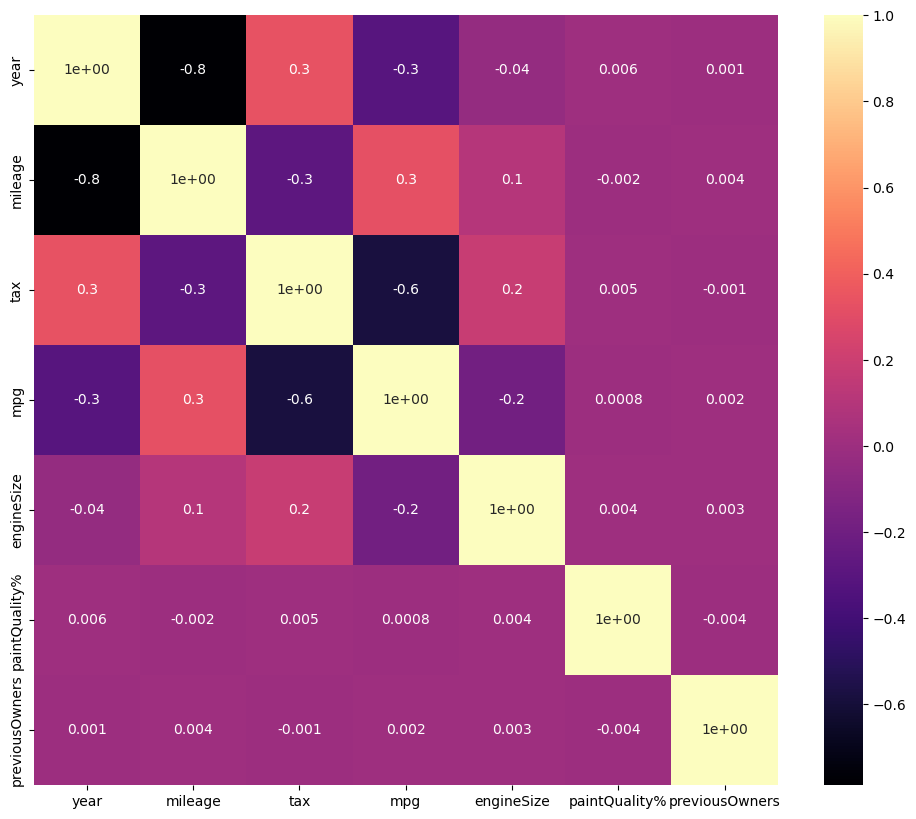

In [18]:
cor_heatmap(cor_spearman)

A  redundacy threshold of 0.85 is applied, ensuring the removal of features that are entirely redundant and the loss of information is minimal.

The heatmap shows that year and mileage are highly related, but not strictly redundant. The correlation betweem them (- 0.8) did not meet the => threshold, so we keep both.

### Test ANOVA F-statistics

We performed the analysis of Variance (ANOVA) F-Test to asses predictive importance of our categorical features (Brand, model, transmission, fuelType, stated_no_damage) with respect to the continuos target vatiable (price)

This test is more statistically appropriate method than the Chi-Square test, which is only valid for comparing two categorical variables. It would have required us to bin the continuos target , which results in loss of information and statistical power.


In [19]:
df_cat = X_train_raw.select_dtypes(exclude=np.number).set_index(X_train_raw.index)
print(df_cat)

          Brand     model transmission fuelType  stated_no_damage
0            vw      golf    semi-auto   petrol              True
1        toyota     yaris       manual   petrol              True
2          audi        q2    semi-auto   petrol              True
3          ford    fiesta       manual   petrol              True
4           bmw  2 series       manual   petrol              True
...         ...       ...          ...      ...               ...
75968  mercedes   c class       manual   petrol              True
75969      audi        q3    semi-auto   diesel              True
75970    toyota      aygo    automatic   petrol              True
75971      audi        q3       manual   diesel              True
75972      ford    fiesta       manual   petrol              True

[75973 rows x 5 columns]


In [20]:
y_train = df_train['price']

In [21]:
def TestIndependence_ANOVA(X, y, var, alpha=0.05):
    """
    Checks independence of a categorical feature (X) against a continuous target (y)like price
    using the ANOVA F-test.
    """
    
    #Group the continuous target (price) by the categories 
    categories = X.unique()
    
    # Create a list of price arrays, one for each category
    groups = [y[X == cat].dropna().values for cat in categories if pd.notna(cat)]
    
    # Filter out categories with too few observations
    valid_groups = [g for g in groups if len(g) > 1]

    if len(valid_groups) < 2:
        print(f"Skipping {var}: Insufficient variance or only one valid group.")
        return

    # Perform the ANOVA F-test
    f_stat, p_value = stats.f_oneway(*valid_groups)
    
    # Decision Rule (p-value < alpha means DEPENDENCE/IMPORTANCE)
    if p_value < alpha:
        result=" {0} is NOT independent of price (p={1:.10f}). It is IMPORTANT for Prediction.".format(var, p_value)
    else:
        result=" {0} is independent of price (p={1:.10f}). It is NOT an important predictor. (Drop {0})".format(var, p_value)
        
    print(result)


print("--- ANOVA F-TEST RESULTS (Test of Independence vs. PRICE, ALPHA = 0.05) ---")
for var in df_cat.columns:
    TestIndependence_ANOVA(df_cat[var], y_train, var)

--- ANOVA F-TEST RESULTS (Test of Independence vs. PRICE, ALPHA = 0.05) ---
 Brand is NOT independent of price (p=0.0000000000). It is IMPORTANT for Prediction.
 model is NOT independent of price (p=0.0000000000). It is IMPORTANT for Prediction.
 transmission is NOT independent of price (p=0.0000000000). It is IMPORTANT for Prediction.
 fuelType is NOT independent of price (p=0.0000000000). It is IMPORTANT for Prediction.
 stated_no_damage is independent of price (p=0.7951177587). It is NOT an important predictor. (Drop stated_no_damage)


It tests the following hypothesis for each categorical feature:

H0 : The mean of price is the same in all categories ( feature independent from price)

H1: At least one category's mean price is significantly different ( feature dependent on price, important for prediction) 

With a significance level of 0.05, we drop the feature 'stated_no_damage' because its pvalue is very high (0.79) and we fail to reject the Null Hypothesis (H0)

<hr>

### Numerical Data

| Predictor | Spearman | 
| --- | --- | 
| year | Keep |
| mileage | Keep |
| tax | Keep | 
| mpg | Keep|
| engineSize | Keep | 
| paintQuality% | Keep | 
| previousOwners | Keep | 



<hr>


### Categorical Data

| Predictor | ANOVA F-statistics | 
| --- | --- | 
| Brand | Keep | 
| model| Keep | 
| transmission | Keep| 
| fuelType | Keep | 
| stated_no_damage | Discard | 





<hr>

# Preprocessing, train and selection

In the next cells we will analyse the dataset, looking for data distributions, fitting some baseline models to have a preliminary ideas on their strenght, selecting the best one between them and apply some fine tuning to get the best of it

In [10]:
df_train = pd.read_csv(
    "https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/train.csv"
)

df_test = pd.read_csv(
    "https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/test.csv"
)

df, df_test = clean_car_data(df_train, df_test, fast=True)

In [11]:
df_test.head()

,carID,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,stated_no_damage
0,89856,hyundai,i30,2023.0,automatic,30700.0,petrol,205.0,41.5,1.6,61.0,3.0,True
1,106581,vw,tiguan,2017.0,semi-auto,48191.0,petrol,150.0,38.2,2.0,60.0,2.0,True
2,80886,bmw,2 series,2016.0,automatic,36792.0,petrol,125.0,51.4,1.5,94.0,2.0,True
3,100174,opel,grandland x,2019.0,manual,5533.0,petrol,145.0,44.1,1.2,77.0,1.0,True
4,81376,bmw,1 series,2019.0,semi-auto,9058.0,diesel,150.0,51.4,2.0,45.0,4.0,True


After uploading the datasets and calling the preprocessing function we will now look at the data to see if we have possible problematic patterns. 

To make the work easier we will transform year and stated_no_damage to integers and set the car id as the index

In [12]:
df["year"] = df["year"].astype(int)
df["stated_no_damage"] = df["stated_no_damage"].astype(int)
df.set_index("carID", inplace=True)

In [13]:
df_num = df[["year", "price", "mileage", "tax", "mpg", "engineSize","paintQuality%", "previousOwners", "stated_no_damage"]]


In [14]:
df_cat = df[["Brand", "model", "transmission", "fuelType"]]


We will now take a look at the distrubution of the data to understand which preprocessing and encoding functions will be more suitable

In [15]:
freq_brand = df_cat["Brand"].value_counts()
print(freq_brand)

Brand
ford        16389
mercedes    11918
vw          10604
opel         9541
bmw          7542
audi         7460
toyota       4715
skoda        4382
hyundai      3422
Name: count, dtype: int64


In [16]:
model_freq = df_cat["model"].value_counts()
print(model_freq)

model
focus       7160
c class     5486
fiesta      4490
golf        3457
corsa       2480
            ... 
230            1
fox            1
veloste        1
s5             1
terracan       1
Name: count, Length: 194, dtype: int64


In [17]:
freq_trans = df_cat["transmission"].value_counts()
print(freq_trans)

transmission
manual       43804
semi-auto    16945
automatic    15224
Name: count, dtype: int64


In [18]:
freq_fuel = df_cat["fuelType"].value_counts()
print(freq_fuel)

fuelType
petrol      41449
diesel      30918
hybrid       3209
electric      397
Name: count, dtype: int64


In [19]:
freq_year = df["year"].value_counts()
print(freq_year)

year
2019    20440
2017    16527
2016    11708
2018    10849
2015     5820
2020     3174
2014     2975
2013     1951
2011      576
2012      490
2010      334
2023      230
2009      228
2008      159
2024      128
2007      124
2005       64
2006       62
2004       35
2003       30
2002       25
2001       15
2000        6
2022        5
1998        5
1999        5
2021        3
1970        2
1997        2
1996        1
Name: count, dtype: int64


In [20]:
freq_damage = df["stated_no_damage"].value_counts()
print(freq_damage)

stated_no_damage
1    74425
0     1548
Name: count, dtype: int64


Some insights that came from the previous code:

1. The year columns has a very skewed distribution, this would suggest the use of a scaler resistant to outliers, in this case RobustScaler
2. The column model for a normal machine learning model has too many values for a categorical encoding, we decided to drop it
3. The other categorical columns present less values, then are suited for a OneHotEncoding
4. The dataset is imbalanced with respect to certain classes

In [21]:
df_models = df.copy()

In [22]:
df = df.drop(["model"], axis=1)        


## Baseline Models

In this section we decided to fit the baseline of several models to understand from a preliminary point of view which will probably be the chosen one. To sum the results we decided to consider the following metrics:

* RMSE
* MAE
* R^2

The results with the cross validation are the following

| Model               | Results                                         |
|--------------------|-------------------------------------------------|
| Linear Regression   | RMSE -> 5025  <br> MAE -> 3141 <br> R² -> 0.733 |
| Ridge Regression    | RMSE -> 5025 <br> MAE -> 3141 <br> R² -> 0.733    |
| Lasso Regression    | RMSE -> 5025 <br> MAE -> 3141 <br> R² -> 0.733     |
| ElasticNet          | RMSE -> 6053 <br> MAE -> 3598 <br> R² -> 0.614     |
| SVR                 | RMSE -> 8223 <br> MAE -> 5093 <br> R² -> 0.287    |
| Random Forest       | RMSE -> 2718 <br> MAE -> 1548 <br> R² -> 0.922     |
| Decision Tree       | RMSE -> 3713 <br> MAE -> 2043 <br> R² -> 0.854     |
| KNeighborsRegressor | RMSE -> 3528 <br> MAE -> 2097 <br> R² -> 0.869     |
| SGDRegressor        | RMSE -> 5030 <br> MAE -> 3139 <br> R² -> 0.733     |


The next consists of four functions that combined together will give us

- Definition of the Adjusted R2 metric
- A function for preprocessing inside the pipeline. It takes the numerical and categorical columns and applies RobustScaler and OneHotEncoder to let them beingsuitable for the models. From that we get the preprocessor object 
- A function that create the pipeline
- A function for the cross-validation that gives us back several metrics for the evaluation. Those will be obtained both from the cross validation validation sets and from sending the training set again inside the model to make predictions, this to understand if we are getting overfitted models. The division between the training sets and the validation sets is done via the use of a multiple stratification approach that divide the data using both brand and the binned price

In [23]:
def adj_r2(y_true, y_pred, n_features):

    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

In [24]:
def create_preprocessing_pipeline():
    """
    Create a preprocessing pipeline for numerical and categorical features.
    
    This function constructs a ColumnTransformer that applies appropriate preprocessing
    to numerical and categorical features. Numerical features are scaled using RobustScaler
    (robust to outliers), while categorical features are one-hot encoded.
    
    Returns
    -------
    ColumnTransformer
        Sklearn ColumnTransformer with two transformers:
        - 'num': RobustScaler for numerical features
        - 'cat': OneHotEncoder for categorical features
        
        All columns not specified in the transformers are dropped.
    """
    
    num_cols = ["year", "mileage", "tax", "mpg", "engineSize",
                "paintQuality%", "previousOwners", "stated_no_damage"]
    cat_cols = ["Brand", "transmission", "fuelType"]
    
    numeric_transformer = RobustScaler()
    categorical_transformer = OneHotEncoder(sparse_output=False, dtype=int, handle_unknown='ignore')
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ],
        remainder='drop'
    )
    
    return preprocessor


In [25]:
def create_full_pipeline(model):
    """
    Create a complete machine learning pipeline with preprocessing and model.
    
    This function constructs a sklearn Pipeline that combines a preprocessing pipeline
    with a given model. The preprocessing pipeline is created via the 
    create_preprocessing_pipeline() function and includes all necessary data 
    transformations (scaling, encoding, feature engineering, etc.).
    
    Parameters
    ----------
    model : estimator object
        Sklearn-compatible model to be used as the final estimator in the pipeline.
        Must implement fit() and predict() methods (e.g., LinearRegression(), 
        RandomForestRegressor(), XGBRegressor()).
    
    Returns
    -------
    Pipeline
        Sklearn Pipeline object with two steps:
        - 'preprocessor': ColumnTransformer with all preprocessing steps
        - 'model': The provided estimator
    """

    preprocessor = create_preprocessing_pipeline()
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    return pipeline

In [30]:
def cross_validation_pipeline(X, y, model, n_folds=5, n_bins=10, random_state=42):
    """
    Perform stratified cross-validation with full pipeline and compute performance metrics.
    
    This function implements stratified cross-validation based on the combination of the
    target variable (binned) and the 'Brand' feature. It uses a complete pipeline that
    includes preprocessing and model, calculating multiple metrics on both training and
    validation sets for each fold.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature dataset. Must contain 'Brand', 'transmission', and 'fuelType' columns
        if present in the original dataset.
    y : pd.Series or np.ndarray
        Target variable (continuous).
    model : estimator object
        Sklearn-compatible model to evaluate (e.g., LinearRegression(), RandomForestRegressor()).
        Must implement fit() and predict() methods.
    n_folds : int, default=5
        Number of folds for stratified k-fold cross-validation.
    n_bins : int, default=10
        Number of bins to discretize the target variable for stratification purposes.
    random_state : int, default=42
        Random seed for reproducibility of fold splits.
    
    Returns
    -------
    dict
        Dictionary containing:
        - 'mean_metrics_val' : dict
            Mean metrics computed on validation sets across folds.
        - 'std_metrics_val' : dict
            Standard deviations of metrics on validation sets.
        - 'mean_metrics_train' : dict
            Mean metrics computed on training sets across folds.
        - 'std_metrics_train' : dict
            Standard deviations of metrics on training sets.
        - 'cv_results' : dict
            Complete results from sklearn's cross_validate function.
        - 'fitted_pipeline' : Pipeline
            Complete pipeline fitted on the entire dataset X, y.
    """
    cat_cols = ["Brand", "transmission", "fuelType"]
    X = X.copy()
    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].astype(str)
    

    y_bins = pd.cut(y, bins=n_bins, labels=False)
    strat_col = y_bins.astype(str) + '_' + X['Brand'].astype(str)
    strat_labels = pd.factorize(strat_col)[0]
    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    

    pipeline = create_full_pipeline(model)

    def rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))
    
    def adj_r2_scorer(estimator, X, y):
        y_pred = estimator.predict(X)
        X_transformed = estimator.named_steps['preprocessor'].transform(X)
        n_features = X_transformed.shape[1]
        return adj_r2(y, y_pred, n_features)
    
    scoring = {
        'MSE': make_scorer(mean_squared_error, greater_is_better=False),
        'RMSE': make_scorer(rmse, greater_is_better=False),
        'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
        'R2': make_scorer(r2_score),
        'ADJ-R2': make_scorer(adj_r2_scorer),
        'MedAE': make_scorer(median_absolute_error, greater_is_better=False),
        'MAPE': make_scorer(mean_absolute_percentage_error, greater_is_better=False)
    }
    
    cv_results = cross_validate(
        pipeline, 
        X, 
        y, 
        cv=skf.split(X, strat_labels),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1, 
        verbose=1
    )
    
    mean_metrics_val = {}
    std_metrics_val = {}
    for metric_name in scoring.keys():
        scores = cv_results[f'test_{metric_name}']
        if metric_name in ['MSE', 'RMSE', 'MAE', 'MedAE', 'MAPE']:
            scores = -scores
        mean_metrics_val[metric_name] = np.mean(scores)
        std_metrics_val[metric_name] = np.std(scores)
    

    mean_metrics_train = {}
    std_metrics_train = {}
    for metric_name in scoring.keys():
        scores = cv_results[f'train_{metric_name}']
        if metric_name in ['MSE', 'RMSE', 'MAE', 'MedAE', 'MAPE']:
            scores = -scores
        mean_metrics_train[metric_name] = np.mean(scores)
        std_metrics_train[metric_name] = np.std(scores)
    
    fitted_pipeline = create_full_pipeline(model)
    fitted_pipeline.fit(X, y)
    

    print(f"\n{'='*80}")
    print("Cross-Validation")
    print(f"{'='*80}\n")
    
    print("VALIDATION SET:")
    print("-" * 80)
    for metric_name in mean_metrics_val.keys():
        print(f"{metric_name:12s}: {mean_metrics_val[metric_name]:10.4f} (±{std_metrics_val[metric_name]:8.4f})")
    
    print(f"\nTRAINING SET:")
    print("-" * 80)
    for metric_name in mean_metrics_train.keys():
        print(f"{metric_name:12s}: {mean_metrics_train[metric_name]:10.4f} (±{std_metrics_train[metric_name]:8.4f})")
    print(f"{'='*80}\n")
    
    return {
        'mean_metrics_val': mean_metrics_val,
        'std_metrics_val': std_metrics_val,
        'mean_metrics_train': mean_metrics_train,
        'std_metrics_train': std_metrics_train,
        'cv_results': cv_results,
        'fitted_pipeline': fitted_pipeline
    }


In [31]:
X = df.drop('price', axis=1)  
y = df['price']

### Training the models and assessing their performances

#### We will train the following baseline models using 10 fold cross validation. To assess the performace with respect to overfitting we will confront the results of the train set after passing it again in the model.

Linear Regression

In [28]:
pipe_linear = LinearRegression()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_linear,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   11.9s remaining:    7.9s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   12.5s finished



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 25270719.9151 (±1120227.8273)
RMSE        :  5025.7450 (±112.2794)
MAE         :  3141.8469 (± 30.9199)
R2          :     0.7335 (±  0.0097)
ADJ-R2      :        nan (±     nan)
MedAE       :  2160.0618 (± 20.6594)
MAPE        :     0.2313 (±  0.0061)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         : 25238728.1907 (±124181.1443)
RMSE        :  5023.8009 (± 12.3501)
MAE         :  3140.5571 (±  4.0561)
R2          :     0.7338 (±  0.0011)
ADJ-R2      :        nan (±     nan)
MedAE       :  2158.7436 (±  3.3522)
MAPE        :     0.2312 (±  0.0007)



In [37]:
fitted_pipeline_linear = results['fitted_pipeline']
fitted_pipeline_linear


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The linear regression model shows balanced performance between training and validation data, indicating good generalization with no overfitting. It explains roughly 73% of the variance (R² ≈ 0.73) in the target, meaning the linear relationships in the features capture a substantial portion of the pricing behavior. The average prediction error is around €3k–€5k (MAE/RMSE), which suggests that while the model follows general market trends, the remaining variance likely comes from non-linear factors or features not captured in the dataset.

Ridge

In [38]:
pipe_ridge = Ridge()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_ridge,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.4s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.5s finished



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 25270637.9627 (±1120179.2060)
RMSE        :  5025.7370 (±112.2745)
MAE         :  3141.8150 (± 30.9258)
R2          :     0.7335 (±  0.0097)
ADJ-R2      :        nan (±     nan)
MedAE       :  2160.1268 (± 20.7255)
MAPE        :     0.2313 (±  0.0061)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         : 25238649.0592 (±124176.4272)
RMSE        :  5023.7930 (± 12.3496)
MAE         :  3140.5255 (±  4.0558)
R2          :     0.7338 (±  0.0011)
ADJ-R2      :        nan (±     nan)
MedAE       :  2158.7070 (±  3.3516)
MAPE        :     0.2312 (±  0.0007)



In [39]:
fitted_pipeline_ridge = results['fitted_pipeline']
fitted_pipeline_ridge


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The Ridge regression model shows almost identical performance to the linear model, with R² ≈ 0.73 and very similar MAE/RMSE on both training and validation sets. This indicates that the model generalizes well and that overfitting is minimal. Ridge regularization adds a penalty on large coefficients, shrinking them toward zero to reduce variance and stabilize the model when features are correlated. In this case, the regularization provides a more robust version of linear regression, but the improvement in error is small, suggesting that the dataset already has relatively stable linear relationships and limited multicollinearity issues.

Lasso

In [40]:
pipe_lasso = Lasso()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_lasso,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    1.6s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    2.1s finished



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 25270962.8882 (±1121354.8828)
RMSE        :  5025.7666 (±112.3949)
MAE         :  3141.4910 (± 31.0426)
R2          :     0.7335 (±  0.0097)
ADJ-R2      :        nan (±     nan)
MedAE       :  2160.3984 (± 21.0032)
MAPE        :     0.2313 (±  0.0061)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         : 25239063.8559 (±124176.9140)
RMSE        :  5023.8343 (± 12.3496)
MAE         :  3140.2082 (±  4.0523)
R2          :     0.7338 (±  0.0011)
ADJ-R2      :        nan (±     nan)
MedAE       :  2158.9801 (±  2.9798)
MAPE        :     0.2312 (±  0.0007)



In [41]:
fitted_pipeline_lasso = results['fitted_pipeline']
fitted_pipeline_lasso


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The Lasso regression model achieves similar performance to the linear and Ridge models, with R² ≈ 0.73 and consistent error metrics across training and validation sets. This again suggests a stable model with no signs of overfitting. Lasso adds an L1 penalty that pushes some coefficients exactly to zero, effectively performing feature selection by removing less relevant predictors. Since the results are almost unchanged, it indicates that most features contribute useful information and that there is limited benefit from sparsity in this dataset — the underlying relationships remain largely linear without strong redundant predictors.

ElasticNet

In [42]:
pipe_elastic = ElasticNet()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_elastic,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.4s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.6s finished



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 36648164.6749 (±1071358.2673)
RMSE        :  6053.1209 (± 88.8379)
MAE         :  3798.4113 (± 29.9667)
R2          :     0.6135 (±  0.0074)
ADJ-R2      :        nan (±     nan)
MedAE       :  2730.3587 (± 28.2421)
MAPE        :     0.2593 (±  0.0030)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         : 36635408.2970 (±114587.3575)
RMSE        :  6052.7117 (±  9.4623)
MAE         :  3798.0322 (±  2.9210)
R2          :     0.6136 (±  0.0009)
ADJ-R2      :        nan (±     nan)
MedAE       :  2731.4464 (±  3.3845)
MAPE        :     0.2593 (±  0.0002)



In [43]:
fitted_pipeline_elastic = results['fitted_pipeline']
fitted_pipeline_elastic

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


SVMRegressor

In [44]:
pipe_SVR = SVR()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_SVR,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed: 29.6min remaining: 19.7min
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed: 43.0min finished



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 67642093.7092 (±1544692.6551)
RMSE        :  8223.9385 (± 94.4982)
MAE         :  5093.8771 (± 30.1002)
R2          :     0.2866 (±  0.0061)
ADJ-R2      :        nan (±     nan)
MedAE       :  3437.1043 (± 49.1219)
MAPE        :     0.3495 (±  0.0049)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         : 67637240.9376 (±171961.8513)
RMSE        :  8224.1797 (± 10.4472)
MAE         :  5093.3662 (±  4.9986)
R2          :     0.2866 (±  0.0008)
ADJ-R2      :        nan (±     nan)
MedAE       :  3436.1572 (±  7.1791)
MAPE        :     0.3494 (±  0.0005)



In [45]:
fitted_pipeline_SVR = results['fitted_pipeline']
fitted_pipeline_SVR

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Random Forest

In [46]:
pipe_rf = RandomForestRegressor()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_rf,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:  1.6min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  2.4min finished



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 7401828.7609 (±539618.7468)
RMSE        :  2718.8576 (± 98.1947)
MAE         :  1548.8360 (± 16.6022)
R2          :     0.9220 (±  0.0049)
ADJ-R2      :        nan (±     nan)
MedAE       :   929.6530 (±  9.9693)
MAPE        :     0.0960 (±  0.0015)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         : 1048344.1105 (±14888.9927)
RMSE        :  1023.8608 (±  7.2902)
MAE         :   574.6677 (±  0.9611)
R2          :     0.9889 (±  0.0001)
ADJ-R2      :        nan (±     nan)
MedAE       :   340.5740 (±  1.4276)
MAPE        :     0.0356 (±  0.0001)



In [47]:
fitted_pipeline_rf = results['fitted_pipeline']
fitted_pipeline_rf

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Single tree

In [48]:
pipe_tree = DecisionTreeRegressor()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_tree,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    1.3s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    2.2s finished



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 13818077.0328 (±1268237.8787)
RMSE        :  3713.6568 (±163.7988)
MAE         :  2043.4186 (± 21.9933)
R2          :     0.8543 (±  0.0126)
ADJ-R2      :        nan (±     nan)
MedAE       :  1172.9500 (± 28.1979)
MAPE        :     0.1255 (±  0.0016)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         :   842.4708 (±339.7593)
RMSE        :    27.8786 (±  8.0780)
MAE         :     0.2911 (±  0.0820)
R2          :     1.0000 (±  0.0000)
ADJ-R2      :        nan (±     nan)
MedAE       :     0.0000 (±  0.0000)
MAPE        :     0.0000 (±  0.0000)



In [49]:
fitted_pipeline_tree = results['fitted_pipeline']
fitted_pipeline_tree

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


KNRegressor

In [50]:
pipe_KNR= KNeighborsRegressor()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_KNR,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   49.1s remaining:   32.7s



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 12461379.4574 (±621489.3281)
RMSE        :  3528.9633 (± 88.3046)
MAE         :  2097.8224 (± 19.7574)
R2          :     0.8686 (±  0.0055)
ADJ-R2      :        nan (±     nan)
MedAE       :  1312.1200 (± 15.4970)
MAPE        :     0.1297 (±  0.0009)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         : 8114478.9112 (±71844.7749)
RMSE        :  2848.5645 (± 12.6074)
MAE         :  1687.6810 (±  2.7789)
R2          :     0.9144 (±  0.0007)
ADJ-R2      :        nan (±     nan)
MedAE       :  1052.3000 (±  2.3715)
MAPE        :     0.1040 (±  0.0002)



[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.3min finished


In [51]:
fitted_pipeline_knr = results['fitted_pipeline']
fitted_pipeline_knr

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


SGDRegressor

In [52]:
pipe_SGD = SGDRegressor()

results = cross_validation_pipeline(
    X=X,           
    y=y,
    model=pipe_SGD,
    n_folds=10,
    n_bins=5,
    random_state=42
)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.6s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.9s finished



Cross-Validation

VALIDATION SET:
--------------------------------------------------------------------------------
MSE         : 25316542.3044 (±1136165.0872)
RMSE        :  5030.2694 (±113.7181)
MAE         :  3139.9738 (± 30.6127)
R2          :     0.7330 (±  0.0101)
ADJ-R2      :        nan (±     nan)
MedAE       :  2154.9747 (± 40.5052)
MAPE        :     0.2321 (±  0.0062)

TRAINING SET:
--------------------------------------------------------------------------------
MSE         : 25324397.8980 (±167870.6945)
RMSE        :  5032.3076 (± 16.6621)
MAE         :  3137.8296 (± 21.1610)
R2          :     0.7329 (±  0.0015)
ADJ-R2      :        nan (±     nan)
MedAE       :  2153.9530 (± 23.0927)
MAPE        :     0.2320 (±  0.0039)



In [53]:
fitted_pipeline_sgd = results['fitted_pipeline']
fitted_pipeline_sgd

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


From the results is clear to see that the best model was the baseline Random Forest. It's also clear that it suffered from overfitting. The second best was less prone but is also much simpler and made more errors. For this submission we will stop the research at the Random Forest. In the next cells we will apply a randomized search for the hyperparameters. In the next submission we plan to going after the overfitting problems.

## Random search on the Random Forest

In [34]:
cat_cols = ["Brand", "transmission", "fuelType"]
X = df.drop('price', axis=1).copy()
y = df['price']
for col in cat_cols:
    if col in X.columns:
        X[col] = X[col].astype(str)


y_bins = pd.cut(y, bins=10, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline = create_full_pipeline(RandomForestRegressor(random_state=42))


In [35]:
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [10, 15, 20, 25, 30, None],
    'model__min_samples_split': [2, 5, 10, 15, 20],
    'model__min_samples_leaf': [1, 2, 4, 6, 8],
    'model__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, None],
    'model__bootstrap': [True, False],
    'model__min_impurity_decrease': [0.0, 0.001, 0.01],
    'model__max_samples': [0.7, 0.8, 0.9, None]}

In [36]:
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=180,                       
    scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
    refit='neg_mean_absolute_error', 
    cv=list(skf.split(X, y_bins)),
    n_jobs=-1,
    verbose=2,
    random_state=42
)


c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [37]:
rs.fit(X, y)

print(f"R2:  {rs.cv_results_['mean_test_r2'][rs.best_index_]:.4f}")
print(f"MSE: {-rs.cv_results_['mean_test_neg_mean_squared_error'][rs.best_index_]:.4f}")
rmse = np.sqrt(-rs.cv_results_['mean_test_neg_mean_squared_error'][rs.best_index_])
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {-rs.cv_results_['mean_test_neg_mean_absolute_error'][rs.best_index_]:.4f}")

print(rs.best_score_)
print(rs.best_params_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


KeyboardInterrupt: 

In [ ]:
best_model = rs.best_estimator_


In [ ]:
import joblib
#joblib.dump(best_model, 'best_rf_model.pkl')
#print(" Model saved as 'best_rf_model.pkl'")

 Model saved as 'best_rf_model.pkl'


In [ ]:
car_ids = df_test['carID'].copy()

feature_cols = X.columns.tolist()  
X_test = df_test[feature_cols].copy()


y_pred = best_model.predict(X_test)

submission = pd.DataFrame({
    'CarID': car_ids,
    'price': y_pred
})
submission.set_index('CarID', inplace=True)

In [ ]:
submission.to_csv('predictions.csv')
print(f" Predictions saved as 'predictions.csv'")
print(f"\nShape: {submission.shape}")
print(submission.head())

 Predictions saved as 'predictions.csv'

Shape: (32567, 1)
               price
CarID               
89856   18366.396465
106581  21932.115823
80886   13792.515784
100174  17281.028174
81376   26818.486697


# System of experts v1.0

Since dropping the column model will remove possible knowledge about price differences we thought about training an ML model specifically for each brand and to connect them to the general model to have more precise results. This is a draft version where we tried to make a simple test on a test-set car.

In [ ]:
df_models.head()

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,stated_no_damage
carID,,,,,,,,,,,,,
69512,vw,golf,2016,22290,semi-auto,28421.0,petrol,176.0,11.4,2.0,63.0,4.0,1
53000,toyota,yaris,2019,13790,manual,4589.0,petrol,145.0,47.9,1.5,50.0,1.0,1
6366,audi,q2,2019,24990,semi-auto,3624.0,petrol,145.0,40.9,1.5,56.0,4.0,1
29021,ford,fiesta,2018,12500,manual,9102.0,petrol,145.0,65.7,1.0,50.0,2.0,1
10062,bmw,2 series,2019,22995,manual,1000.0,petrol,145.0,42.8,1.5,97.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,mercedes,c class,2015,13498,manual,14480.0,petrol,125.0,53.3,2.0,78.0,0.0,1
6265,audi,q3,2013,12495,semi-auto,52134.0,diesel,200.0,47.9,2.0,38.0,2.0,1
54886,toyota,aygo,2017,8399,automatic,11304.0,petrol,145.0,67.0,1.0,57.0,3.0,1


In [59]:
df_models["Brand"].value_counts()

Brand
ford        16389
mercedes    11918
vw          10604
opel         9541
bmw          7542
audi         7460
toyota       4715
skoda        4382
hyundai      3422
Name: count, dtype: int64

In [ ]:
models_per_brand = []
results = []

brands = df_models["Brand"].unique()

for brand in brands:
    print(f"Training model for brand: {brand}")

    df_brand = df_models[df_models["Brand"] == brand]
    

    y_brand = df_brand["price"]
    X_brand = df_brand.drop(columns=["price"]) 
    

    num_cols = X_brand.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X_brand.select_dtypes(include=["object", "bool"]).columns.tolist()
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", RobustScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )
    
    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features=0.5,
            bootstrap=False,
            random_state=42
        ))
    ])
    
    # fit
    pipeline.fit(X_brand, y_brand)
    models_per_brand.append((brand, pipeline))

    y_pred = pipeline.predict(X_brand)
    
    results.append({
        "brand": brand,
        "n_samples": len(X_brand),
        "rmse": np.sqrt(mean_squared_error(y_brand, y_pred)),
        "mae": mean_absolute_error(y_brand, y_pred),
        "r2": r2_score(y_brand, y_pred)
    })

results_df = pd.DataFrame(results)
print("\n Results per Brand:")
print(results_df)


Training model for brand: vw
Training model for brand: toyota
Training model for brand: audi
Training model for brand: ford
Training model for brand: bmw
Training model for brand: skoda
Training model for brand: opel
Training model for brand: mercedes
Training model for brand: hyundai

 Results per Brand:
      brand  n_samples         rmse         mae        r2
0        vw      10604   722.835029  432.359528  0.991264
1    toyota       4715   554.332532  333.677012  0.992381
2      audi       7460   936.807817  562.049547  0.993553
3      ford      16389   551.399943  340.296321  0.986743
4       bmw       7542  1242.649683  592.090118  0.988208
5     skoda       4382   857.623952  389.485379  0.981132
6      opel       9541   455.872219  292.108882  0.983598
7  mercedes      11918  1162.720781  635.426888  0.989210
8   hyundai       3422   599.604634  362.804299  0.990025


In [61]:
class PricePredictor:
    def __init__(self, general_model, brand_models):
        self.general_model = general_model
        self.brand_models = dict(brand_models) 
    
    def predict(self, X, use_brand_model=True):
        preds = []
        for idx, row in X.iterrows():
            brand = row["Brand"]
            if use_brand_model and brand in self.brand_models:
                model = self.brand_models[brand]
            else:
                model = self.general_model

            preds.append(model.predict(row.to_frame().T)[0])
        
        return np.array(preds)


In [62]:
predictor = PricePredictor(general_model=rs.best_estimator_, brand_models=models_per_brand)
data = {
    "Brand": ["Hyundai"],
    "model": ["I30"],
    "year": [2022.8780055401344],
    "transmission": ["Automatic"],
    "mileage": [30700.0],
    "fuelType": ["petrol"],
    "tax": [205.0],
    "mpg": [41.5],
    "engineSize": [1.6],
    "paintQuality%": [61.0],
    "previousOwners": [3.0],
    "stated_no_damage": [0.0]
}

single_car_df = pd.DataFrame(data)

y_pred_general = predictor.predict(single_car_df, use_brand_model=False)

y_pred_brand = predictor.predict(single_car_df, use_brand_model=True)

print(f"General Model prediction: {y_pred_general[0]:.2f}")
print(f"Expert Model prediction: {y_pred_brand[0]:.2f}")


General Model prediction: 18900.21
Expert Model prediction: 18900.21
